## Case Study: MovieLens 100K Dataset

Now that we've practiced the core pandas methods on a small synthetic dataset, let's apply them to a real dataset.

We'll use the **MovieLens 100K** dataset, which contains:

- **100,000 ratings** from 943 users on 1,682 movies
  
- User demographic information (age, gender, occupation, zip code)
  
- Movie information (title, release date, genres)

**Data Source:** MovieLens website
**Location:** https://grouplens.org/datasets/movielens/100k/

Please download the dataset and place the files in a folder called **movielens/ml-100k** in your lecture folder for this week.

## Importing the Dataset

This dataset comes as three separate files, and none of them include column headers, so we need to supply the column names ourselves.

- **u.user** : User demographics (pipe `|` separated): user id, age, gender, occupation, zip code
  
- **u.item** : Movie information (pipe `|` separated): movie id, title, release date, and more
  
- **u.data** : Ratings (tab separated): user id, movie id, rating, timestamp

In [94]:
import pandas as pd

### Loading Users

In [95]:
user_columns = ['user_id', 'age', 'gender', 'occupation', 'zipcode']

users = pd.read_csv('movielens/ml-100k/u.user', sep='|', names=user_columns)
users.head()

,user_id,age,gender,occupation,zipcode
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


### Loading Movies

In [96]:
movie_columns = ['movie_id', 'movie_title', 'release_date', 'video_release_date', 'imdb_url',
                  'unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
                  'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

movies = pd.read_csv('movielens/ml-100k/u.item', sep='|', names=movie_columns, encoding='latin-1')
movies.head()

,movie_id,movie_title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Childrens,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


Note: this file needs `encoding='latin-1'` since some movie titles contain special characters that aren't valid in the default UTF-8 encoding.

### Loading Ratings

In [97]:
rating_columns = ['user_id', 'movie_id', 'rating', 'timestamp']

ratings = pd.read_csv('movielens/ml-100k/u.data', sep='\t', names=rating_columns)
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


### Class Exercise: Initial Data Exploration (5 points)

Using the `users`, `movies`, and `ratings` DataFrames, answer the following:

- What is the shape of each DataFrame?
  
- What are the column names in `movies`?
  
- What is the data type of the `age` column in `users`?
  
- Show the last 5 rows of `ratings`
  
- How many unique users are in `users`? (**HINT:** use `.nunique()`)
  
- How many unique movies are in `movies`?
  

In [ ]:
#What is the shape of each DataFrame?

# YOUR CODE HERE


In [ ]:
#What are the column names in movies?

# YOUR CODE HERE


In [ ]:
#What is the data type of the age column in users?

# YOUR CODE HERE


In [ ]:
#Show the last 5 rows of ratings

# YOUR CODE HERE


In [ ]:
#How many unique users are in users? (HINT: use .nunique())

# YOUR CODE HERE


In [ ]:
#How many unique movies are in movies?

# YOUR CODE HERE


## Data Cleaning

Before analyzing any dataset, it's important to check for missing values and remove columns that don't add value.

Let's check each DataFrame for missing values.

In [98]:
users.isnull().sum()

user_id       0
age           0
gender        0
occupation    0
zipcode       0
dtype: int64

In [99]:
movies.isnull().sum()

movie_id                 0
movie_title              0
release_date             1
video_release_date    1682
imdb_url                 3
unknown                  0
Action                   0
Adventure                0
Animation                0
Childrens                0
Comedy                   0
Crime                    0
Documentary              0
Drama                    0
Fantasy                  0
Film-Noir                0
Horror                   0
Musical                  0
Mystery                  0
Romance                  0
Sci-Fi                   0
Thriller                 0
War                      0
Western                  0
dtype: int64

In [100]:
ratings.isnull().sum()

user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

`movies` has missing values in a few columns. Let's take a closer look at `video_release_date`.

In [101]:
movies['video_release_date'].isnull().sum()

np.int64(1682)

In [102]:
movies.shape

(1682, 24)

In [103]:
movies.head()

,movie_id,movie_title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Childrens,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


Since `video_release_date` is missing for every single row, it doesn't carry any useful information, so we can drop the entire column.

In [104]:
movies = movies.drop(columns=['video_release_date'])
movies.head()

,movie_id,movie_title,release_date,imdb_url,unknown,Action,Adventure,Animation,Childrens,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


There's also an `unknown` column, which is a genre flag left over from older, poorly-categorized entries in the dataset. Since it doesn't correspond to a real genre, we'll drop it too.

In [105]:
movies = movies.drop(columns=['unknown'])
movies.head()

,movie_id,movie_title,release_date,imdb_url,Action,Adventure,Animation,Childrens,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?GoldenEye%20(...,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Get%20Shorty%...,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


Now let's check for any remaining missing values, and handle any leftover rows with nulls.

In [106]:
movies.isnull().sum()

movie_id        0
movie_title     0
release_date    1
imdb_url        3
Action          0
Adventure       0
Animation       0
Childrens       0
Comedy          0
Crime           0
Documentary     0
Drama           0
Fantasy         0
Film-Noir       0
Horror          0
Musical         0
Mystery         0
Romance         0
Sci-Fi          0
Thriller        0
War             0
Western         0
dtype: int64

Missing information in release_date and imdb_url is minimal, so we can drop off the data rows.

In [107]:
movies = movies.dropna()

In [108]:
movies.isnull().sum()

movie_id        0
movie_title     0
release_date    0
imdb_url        0
Action          0
Adventure       0
Animation       0
Childrens       0
Comedy          0
Crime           0
Documentary     0
Drama           0
Fantasy         0
Film-Noir       0
Horror          0
Musical         0
Mystery         0
Romance         0
Sci-Fi          0
Thriller        0
War             0
Western         0
dtype: int64

### Class Exercise: Data Cleaning (2 points)

- Check if there are any duplicate rows in `users`, `movies`, and `ratings` (**HINT:** use `.duplicated().sum()`)
  
- If any duplicates exist, drop them (**HINT:** use `.drop_duplicates()`)
  
- Verify the new shape of each DataFrame after dropping duplicates

In [109]:
#Check if there are any dubplicate rows in users
# YOUR CODE HERE
users.duplicated().sum()

np.int64(0)

In [110]:
#Check if there are any dubplicate rows in movies
# YOUR CODE HERE
movies.duplicated().sum()

np.int64(0)

In [111]:
#Check if there are any dubplicate rows in ratings
# YOUR CODE HERE
ratings.duplicated().sum()

np.int64(0)

## Data Manipulation

Now let's practice combining and reshaping data, selecting specific columns/rows, grouping and aggregating, merging DataFrames together, and working with text and dates.

In this section, we will cover:

- Selecting specific columns and rows
  
- Filtering with string conditions
  
- Group by and aggregate
  
- Merging DataFrames
  
- Working with timestamps

### Selecting Columns and Rows

We already saw basic filtering with boolean masks earlier. Let's now practice selecting specific columns and rows directly, using our MovieLens DataFrames.

In [112]:
users.head()

,user_id,age,gender,occupation,zipcode
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [113]:
# Extract only the occupation column
users['occupation'].head()

0    technician
1         other
2        writer
3    technician
4         other
Name: occupation, dtype: object

In [114]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [115]:
# Select rows from index 5 to 14 in ratings
ratings[5:15]

,user_id,movie_id,rating,timestamp
5,298,474,4,884182806
6,115,265,2,881171488
7,253,465,5,891628467
8,305,451,3,886324817
9,6,86,3,883603013
10,62,257,2,879372434
11,286,1014,5,879781125
12,200,222,5,876042340
13,210,40,3,891035994
14,224,29,3,888104457


### Filtering with String Conditions

We can also filter rows based on whether a text column contains a certain word, using `.str.contains()`.

In [117]:
movies.head(2)

,movie_id,movie_title,release_date,imdb_url,Action,Adventure,Animation,Childrens,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?GoldenEye%20(...,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [119]:
# Find movies with 'Star' in the title

is_star = movies['movie_title'].str.contains('Star')
is_star

0       False
1       False
2       False
3       False
4       False
        ...  
1677    False
1678    False
1679    False
1680    False
1681    False
Name: movie_title, Length: 1679, dtype: bool

In [120]:
movies[is_star]

,movie_id,movie_title,release_date,imdb_url,Action,Adventure,Animation,Childrens,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
49,50,Star Wars (1977),01-Jan-1977,http://us.imdb.com/M/title-exact?Star%20Wars%2...,1,1,0,0,0,0,...,0,0,0,0,0,1,1,0,1,0
61,62,Stargate (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Stargate%20(1...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
123,124,Lone Star (1996),21-Jun-1996,http://us.imdb.com/M/title-exact?Lone%20Star%2...,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
145,146,Unhook the Stars (1996),30-Oct-1996,http://us.imdb.com/M/title-exact?Unhook%20the%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
221,222,Star Trek: First Contact (1996),22-Nov-1996,http://us.imdb.com/M/title-exact?Star%20Trek:%...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
226,227,Star Trek VI: The Undiscovered Country (1991),01-Jan-1991,http://us.imdb.com/M/title-exact?Star%20Trek%2...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
227,228,Star Trek: The Wrath of Khan (1982),01-Jan-1982,http://us.imdb.com/M/title-exact?Star%20Trek:%...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
228,229,Star Trek III: The Search for Spock (1984),01-Jan-1984,http://us.imdb.com/M/title-exact?Star%20Trek%2...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
229,230,Star Trek IV: The Voyage Home (1986),01-Jan-1986,http://us.imdb.com/M/title-exact?Star%20Trek%2...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
270,271,Starship Troopers (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?Starship+Troo...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0


### Group By and Aggregate

Grouping lets us split data into categories and then compute a summary statistic for each group, for example, the average rating given by each user, or the count of ratings per movie.

In [121]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [122]:
# Count how many ratings each movie received

rating_counts = ratings[['movie_id', 'rating']].groupby('movie_id').count()



In [123]:
ratings_counts.head()

,rating
movie_id,
1,452
2,131
3,90
4,209
5,86


In [124]:
# Average rating for each movie
average_rating = ratings[['movie_id', 'rating']].groupby('movie_id').mean()
average_rating.head()

,rating
movie_id,
1,3.878319
2,3.206107
3,3.033333
4,3.550239
5,3.302326


Another example

In [125]:
users

,user_id,age,gender,occupation,zipcode
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213
...,...,...,...,...,...
938,939,26,F,student,33319
939,940,32,M,administrator,02215
940,941,20,M,student,97229
941,942,48,F,librarian,78209


In [129]:
users[['occupation','gender', 'age']].groupby(['occupation','gender']).mean()

age
occupation    gender           
administrator F       40.638889
              M       37.162791
artist        F       30.307692
              M       32.333333
doctor        M       43.571429
educator      F       39.115385
              M       43.101449
engineer      F       29.500000
              M       36.600000
entertainment F       31.000000
              M       29.000000
executive     F       44.000000
              M       38.172414
healthcare    F       39.818182
              M       45.400000
homemaker     F       34.166667
              M       23.000000
lawyer        F       39.500000
              M       36.200000
librarian     F       40.000000
              M       40.000000
marketing     F       37.200000
              M       37.875000
none          F       36.500000
              M       18.600000
other         F       35.472222
              M       34.028986
programmer    F       32.166667
              M       33.216667
retired       F       70.000000
              M       62.538462
salesman      F       27.000000
              M       38.555556
scientist     F       28.333333
              M       36.321429
student       F       20.750000
              M       22.669118
technician    F       38.000000
              M       32.961538
writer        F       37.631579
              M       35.346154

In [130]:
users[['occupation','gender', 'age']].groupby(['gender','occupation']).mean()

age
gender occupation              
F      administrator  40.638889
       artist         30.307692
       educator       39.115385
       engineer       29.500000
       entertainment  31.000000
       executive      44.000000
       healthcare     39.818182
       homemaker      34.166667
       lawyer         39.500000
       librarian      40.000000
       marketing      37.200000
       none           36.500000
       other          35.472222
       programmer     32.166667
       retired        70.000000
       salesman       27.000000
       scientist      28.333333
       student        20.750000
       technician     38.000000
       writer         37.631579
M      administrator  37.162791
       artist         32.333333
       doctor         43.571429
       educator       43.101449
       engineer       36.600000
       entertainment  29.000000
       executive      38.172414
       healthcare     45.400000
       homemaker      23.000000
       lawyer         36.200000
       librarian      40.000000
       marketing      37.875000
       none           18.600000
       other          34.028986
       programmer     33.216667
       retired        62.538462
       salesman       38.555556
       scientist      36.321429
       student        22.669118
       technician     32.961538
       writer         35.346154

### Merging DataFrames

So far, we've worked with `users`, `movies`, and `ratings` separately. But often questions require combining them, for example, "what's the average rating per genre?" needs both `movies` and `ratings` together.

`pd.merge()` combines two DataFrames based on a shared column, similar to a SQL join.

In [131]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [132]:
movies.head()

,movie_id,movie_title,release_date,imdb_url,Action,Adventure,Animation,Childrens,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?GoldenEye%20(...,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Get%20Shorty%...,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


In [133]:
# Merge ratings and movies on movie_id, using an inner join
ratings_movies = pd.merge(ratings, movies, on='movie_id', how='inner')
ratings_movies.head()

,user_id,movie_id,rating,timestamp,movie_title,release_date,imdb_url,Action,Adventure,Animation,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,0,...,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,0,...,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,0,...,0,0,0,0,0,0,0,0,0,0


An **inner join** keeps only the rows where the matching value (`movie_id`) exists in *both* DataFrames.

More on join types: https://pandas.pydata.org/docs/user_guide/merging.html

We can also merge `ratings` with `users` to bring in demographic info alongside each rating.

In [134]:
users.head()

,user_id,age,gender,occupation,zipcode
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [135]:
ratings_users = pd.merge(ratings, users, on='user_id', how='inner')
ratings_users.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zipcode
0,196,242,3,881250949,49,M,writer,55105
1,186,302,3,891717742,39,F,executive,00000
2,22,377,1,878887116,25,M,writer,40206
3,244,51,2,880606923,28,M,technician,80525
4,166,346,1,886397596,47,M,educator,55113


And we can chain merges together, combining all three DataFrames into one.

In [136]:
full_df = pd.merge(ratings_movies, users, on='user_id', how='inner')
full_df.head()

,user_id,movie_id,rating,timestamp,movie_title,release_date,imdb_url,Action,Adventure,Animation,...,Mystery,Romance,Sci-Fi,Thriller,War,Western,age,gender,occupation,zipcode
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,0,...,0,0,0,0,0,0,49,M,writer,55105
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,0,...,1,0,0,1,0,0,39,F,executive,00000
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,0,...,0,0,0,0,0,0,25,M,writer,40206
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,0,...,0,1,0,0,1,1,28,M,technician,80525
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,0,...,0,0,0,0,0,0,47,M,educator,55113


### Working with Timestamps

The `timestamp` column in `ratings` records when each rating was made, but it's stored as raw seconds since midnight UTC, January 1, 1970. Let's convert it into an actual date so it's usable.

In [137]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [138]:
ratings.dtypes

user_id      int64
movie_id     int64
rating       int64
timestamp    int64
dtype: object

In [139]:
# Convert timestamp into a proper datetime column

ratings['rating_date'] = pd.to_datetime(ratings['timestamp'], unit='s')


In [140]:
ratings.head()

,user_id,movie_id,rating,timestamp,rating_date
0,196,242,3,881250949,1997-12-04 15:55:49
1,186,302,3,891717742,1998-04-04 19:22:22
2,22,377,1,878887116,1997-11-07 07:18:36
3,244,51,2,880606923,1997-11-27 05:02:03
4,166,346,1,886397596,1998-02-02 05:33:16


In [141]:
ratings.dtypes

user_id                 int64
movie_id                int64
rating                  int64
timestamp               int64
rating_date    datetime64[ns]
dtype: object

Now that `rating_date` is a real datetime column, we can filter by date ranges, sort by date, and extract parts of the date (year, month, etc.).

In [142]:
# Select ratings made after a certain date
recent_ratings = ratings[ratings['rating_date'] > '1998-01-01']
recent_ratings.head()

,user_id,movie_id,rating,timestamp,rating_date
1,186,302,3,891717742,1998-04-04 19:22:22
4,166,346,1,886397596,1998-02-02 05:33:16
5,298,474,4,884182806,1998-01-07 14:20:06
7,253,465,5,891628467,1998-04-03 18:34:27
8,305,451,3,886324817,1998-02-01 09:20:17


In [143]:
ratings.shape, recent_ratings.shape

((100000, 5), (47101, 5))

In [144]:
# Sort ratings by date, earliest first
ratings_sorted = ratings.sort_values(by='rating_date', ascending=True)
ratings_sorted.head()

,user_id,movie_id,rating,timestamp,rating_date
214,259,255,4,874724710,1997-09-20 03:05:10
83965,259,286,4,874724727,1997-09-20 03:05:27
43027,259,298,4,874724754,1997-09-20 03:05:54
21396,259,185,4,874724781,1997-09-20 03:06:21
82655,259,173,4,874724843,1997-09-20 03:07:23


In [145]:
# Extract just the year from rating_date
ratings['rating_year'] = ratings['rating_date'].dt.year
ratings.head()

,user_id,movie_id,rating,timestamp,rating_date,rating_year
0,196,242,3,881250949,1997-12-04 15:55:49,1997
1,186,302,3,891717742,1998-04-04 19:22:22,1998
2,22,377,1,878887116,1997-11-07 07:18:36,1997
3,244,51,2,880606923,1997-11-27 05:02:03,1997
4,166,346,1,886397596,1998-02-02 05:33:16,1998


### Class Exercise: Data Manipulation (5 points)

Using the `users`, `movies`, and `ratings` DataFrames, answer the following:

- Filter `movies` to show only movies with `'Trek'` in the title
  
- Merge `ratings` and `movies` on `movie_id` using an inner join
  
- Using the merged DataFrame, find the average rating for each `movie_title` (**HINT:** use `.groupby()`
  
- Convert the `timestamp` column in `ratings` to a proper datetime column
  
- Extract the year from the converted date, and find the average rating given per year

In [146]:
# Filter movies with 'Trek' in the title

# YOUR CODE HERE
is_trek = movies['movie_title'].str.contains('Trek')
movies[is_trek]

,movie_id,movie_title,release_date,imdb_url,Action,Adventure,Animation,Childrens,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
221,222,Star Trek: First Contact (1996),22-Nov-1996,http://us.imdb.com/M/title-exact?Star%20Trek:%...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
226,227,Star Trek VI: The Undiscovered Country (1991),01-Jan-1991,http://us.imdb.com/M/title-exact?Star%20Trek%2...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
227,228,Star Trek: The Wrath of Khan (1982),01-Jan-1982,http://us.imdb.com/M/title-exact?Star%20Trek:%...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
228,229,Star Trek III: The Search for Spock (1984),01-Jan-1984,http://us.imdb.com/M/title-exact?Star%20Trek%2...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
229,230,Star Trek IV: The Voyage Home (1986),01-Jan-1986,http://us.imdb.com/M/title-exact?Star%20Trek%2...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
379,380,Star Trek: Generations (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Star%20Trek:%...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
448,449,Star Trek: The Motion Picture (1979),01-Jan-1979,http://us.imdb.com/M/title-exact?Star%20Trek:%...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
449,450,Star Trek V: The Final Frontier (1989),01-Jan-1989,http://us.imdb.com/M/title-exact?Star%20Trek%2...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [147]:
# Merge ratings and movies on movie_id

# YOUR CODE HERE
ratings_movies = pd.merge(ratings, movies, on='movie_id', how='inner')
ratings_movies.head()

,user_id,movie_id,rating,timestamp,rating_date,rating_year,movie_title,release_date,imdb_url,Action,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,1997-12-04 15:55:49,1997,Kolya (1996),24-Jan-1997,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,...,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,1998-04-04 19:22:22,1998,L.A. Confidential (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,...,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,1997-11-07 07:18:36,1997,Heavyweights (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Heavyweights%...,0,...,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,1997-11-27 05:02:03,1997,Legends of the Fall (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Legends%20of%...,0,...,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,1998-02-02 05:33:16,1998,Jackie Brown (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?imdb-title-11...,0,...,0,0,0,0,0,0,0,0,0,0


In [148]:
# Average rating for each movie_title

# YOUR CODE HERE
avg_rating_by_title = ratings_movies[['movie_title', 'rating']].groupby('movie_title').mean()
avg_rating_by_title.head()

,rating
movie_title,
'Til There Was You (1997),2.333333
1-900 (1994),2.600000
101 Dalmatians (1996),2.908257
12 Angry Men (1957),4.344000
187 (1997),3.024390


In [149]:
# Convert timestamp to datetime

# YOUR CODE HERE
ratings['rating_date'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings.head()

,user_id,movie_id,rating,timestamp,rating_date,rating_year
0,196,242,3,881250949,1997-12-04 15:55:49,1997
1,186,302,3,891717742,1998-04-04 19:22:22,1998
2,22,377,1,878887116,1997-11-07 07:18:36,1997
3,244,51,2,880606923,1997-11-27 05:02:03,1997
4,166,346,1,886397596,1998-02-02 05:33:16,1998


In [150]:
# Extract year and find average rating per year

# YOUR CODE HERE
ratings['rating_year'] = ratings['rating_date'].dt.year
ratings[['rating_year', 'rating']].groupby('rating_year').mean()

,rating
rating_year,
1997,3.56812
1998,3.48689


## Putting It All Together (5 points)

Let's finish with a combined analysis question that uses everything we've covered, merging, grouping, filtering, and correlation.

### Capstone Exercise

Using the `users`, `movies`, and `ratings` DataFrames, answer the following:

**Question:** Are older users more generous with their ratings than younger users? Is there a relationship between a user's age and the rating they give?

- Merge `ratings` and `users` on `user_id`
  
- Find the correlation between `age` and `rating` (**HINT:** use `.corr()`)
  
- Group the merged data by `age`, and find the average rating per age
  
- Plot the average rating per age as a line chart

In [151]:
# Merge ratings and users on user_id

# YOUR CODE HERE
ratings_users = pd.merge(ratings, users, on='user_id', how='inner')
ratings_users.head()

,user_id,movie_id,rating,timestamp,rating_date,rating_year,age,gender,occupation,zipcode
0,196,242,3,881250949,1997-12-04 15:55:49,1997,49,M,writer,55105
1,186,302,3,891717742,1998-04-04 19:22:22,1998,39,F,executive,00000
2,22,377,1,878887116,1997-11-07 07:18:36,1997,25,M,writer,40206
3,244,51,2,880606923,1997-11-27 05:02:03,1997,28,M,technician,80525
4,166,346,1,886397596,1998-02-02 05:33:16,1998,47,M,educator,55113


In [152]:
# Correlation between age and rating

# YOUR CODE HERE
ratings_users[['age', 'rating']].corr()

,age,rating
age,1.00000,0.05446
rating,0.05446,1.00000


In [153]:
# Average rating per age

# YOUR CODE HERE
avg_rating_by_age = ratings_users[['age', 'rating']].groupby('age').mean()
avg_rating_by_age.head()

,rating
age,
7,3.767442
10,3.387097
11,2.925926
13,3.470825
14,3.375000


<Axes: title={'center': 'Average Rating by Age'}, xlabel='Age', ylabel='Average Rating'>

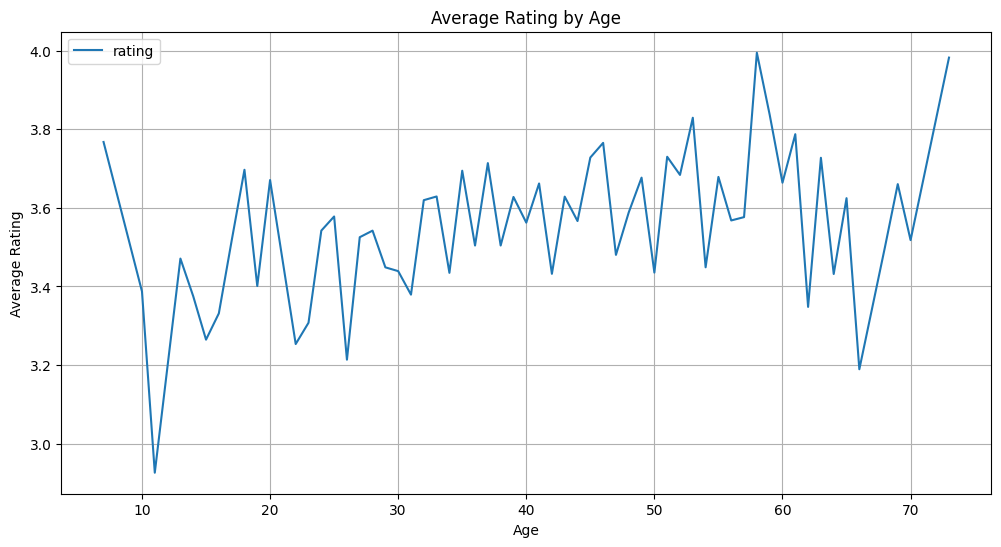

In [154]:
# Plot average rating per age

# YOUR CODE HERE
avg_rating_by_age.plot(kind='line', y='rating', title='Average Rating by Age',
                        xlabel='Age', ylabel='Average Rating', figsize=(12, 6), grid=True)